This project trains a custom CNN from scratch to classify bean leaf images into three classes (healthy, angular leaf spot, bean rust) using the Beans dataset from Hugging Face. The pipeline covers data loading and augmentation, a compact convolutional architecture with global average pooling, training with Adam and cross-entropy loss, and evaluation via accuracy, precision, recall, F1-score, and a confusion matrix, with the final model saved as a lightweight .pth file.

## 1. Import Libraries

**Install packages not pre-installed on Colab**

In [1]:
!pip install -q datasets torchinfo

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from datasets import load_dataset
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Load and Explore Dataset

The `beans` dataset comes with three splits already defined: `train`, `validation`, and `test`. loaded all three directly from the Hugging Face Hub.

In [3]:
raw_datasets = load_dataset("AI-Lab-Makerere/beans")
print(raw_datasets)

class_names = raw_datasets["train"].features["labels"].names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train size:", len(raw_datasets["train"]))
print("Validation size:", len(raw_datasets["validation"]))
print("Test size:", len(raw_datasets["test"]))


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Number of classes: 3
Train size: 1034
Validation size: 133
Test size: 128


   angular_leaf_spot : 345 images
           bean_rust : 348 images
             healthy : 341 images


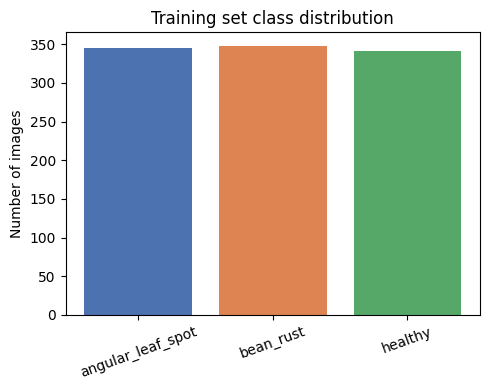

In [4]:
train_labels = raw_datasets["train"]["labels"]
unique, counts = np.unique(train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{class_names[u]:>20s} : {c} images")

plt.figure(figsize=(5, 4))
plt.bar([class_names[u] for u in unique], counts, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Training set class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


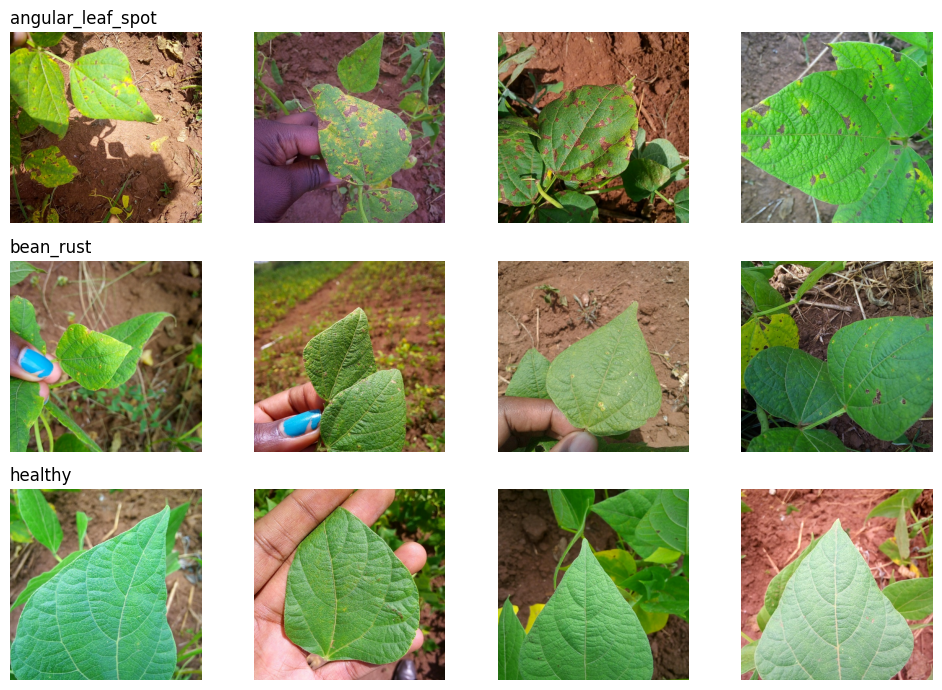

In [5]:
fig, axes = plt.subplots(num_classes, 4, figsize=(10, 7))
for row, cls_idx in enumerate(range(num_classes)):
    subset = [ex for ex in raw_datasets["train"] if ex["labels"] == cls_idx][:4]
    for col, ex in enumerate(subset):
        axes[row, col].imshow(ex["image"])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(class_names[cls_idx])
    axes[row, 0].set_title(class_names[cls_idx], loc="left")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Augmentation

All images are resized to 128×128. Training images get light augmentation (flips, rotation, color jitter) to reduce overfitting, while validation/test images are only resized and normalized — kept consistent for fair evaluation. Normalization uses standard ImageNet mean/std values.

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class BeansTorchDataset(Dataset):
    """Wraps a HuggingFace `datasets` split as a PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        example = self.hf_split[idx]
        image = example["image"].convert("RGB")
        label = example["labels"]
        image = self.transform(image)
        return image, label

train_dataset = BeansTorchDataset(raw_datasets["train"], train_transform)
val_dataset = BeansTorchDataset(raw_datasets["validation"], eval_transform)
test_dataset = BeansTorchDataset(raw_datasets["test"], eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Sanity check on a batch
imgs, labels = next(iter(train_loader))
print("Batch image tensor shape:", imgs.shape)
print("Batch labels shape:", labels.shape)


Train batches: 33 | Val batches: 5 | Test batches: 4
Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch labels shape: torch.Size([32])


## 4. CNN Architecture

A custom CNN with 4 convolutional blocks (Conv → BatchNorm → ReLU → MaxPool), doubling channels from 32 to 256, followed by Global Average Pooling and a small FC classifier head. BatchNorm stabilizes training, Dropout (0.4) prevents overfitting on the small dataset, Global Average Pooling keeps the model compact, and the progressive channel increase lets early layers capture simple features while deeper layers learn more complex, class-specific patterns.

In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)  # -> (256, 1, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = CustomCNN(num_classes=num_classes).to(device)
summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))


Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [32, 3]                   --
├─Sequential: 1-1                        [32, 256, 8, 8]           --
│    └─Sequential: 2-1                   [32, 32, 64, 64]          --
│    │    └─Conv2d: 3-1                  [32, 32, 128, 128]        896
│    │    └─BatchNorm2d: 3-2             [32, 32, 128, 128]        64
│    │    └─ReLU: 3-3                    [32, 32, 128, 128]        --
│    │    └─MaxPool2d: 3-4               [32, 32, 64, 64]          --
│    └─Sequential: 2-2                   [32, 64, 32, 32]          --
│    │    └─Conv2d: 3-5                  [32, 64, 64, 64]          18,496
│    │    └─BatchNorm2d: 3-6             [32, 64, 64, 64]          128
│    │    └─ReLU: 3-7                    [32, 64, 64, 64]          --
│    │    └─MaxPool2d: 3-8               [32, 64, 32, 32]          --
│    └─Sequential: 2-3                   [32, 128, 16, 16]         --
│    │   

In [8]:
num_params = sum(p.numel() for p in model.parameters())
approx_size_mb = num_params * 4 / (1024 ** 2)
print(f"Total parameters: {num_params:,}")
print(f"Approx. saved .pth size: {approx_size_mb:.2f} MB")


Total parameters: 422,659
Approx. saved .pth size: 1.61 MB


## 5. Training Loop with Validation

**Hyperparameters and rationale:**

The model uses Adam optimizer (lr=1e-3) for fast, low-tuning convergence, and CrossEntropyLoss for multi-class classification. A ReduceLROnPlateau scheduler lowers the learning rate when validation loss stalls. Training runs for 25 epochs, saving the checkpoint with the best validation accuracy to guard against late overfitting. Regularization combines Dropout, data augmentation, and weight decay (1e-4).

In [9]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 25

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def run_epoch(loader, model, criterion, optimizer=None):
    """Runs one epoch. If optimizer is provided, trains; otherwise evaluates."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    torch.set_grad_enabled(is_train)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    torch.set_grad_enabled(True)
    return total_loss / total_samples, total_correct / total_samples


In [10]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_path = "best_model.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} (checkpoint saved to '{best_model_path}')")


Epoch 01/25 | Train Loss: 0.9110 Acc: 0.5696 | Val Loss: 0.6860 Acc: 0.7068
Epoch 02/25 | Train Loss: 0.7665 Acc: 0.6634 | Val Loss: 0.6098 Acc: 0.7594
Epoch 03/25 | Train Loss: 0.7283 Acc: 0.6809 | Val Loss: 0.5676 Acc: 0.7669
Epoch 04/25 | Train Loss: 0.6944 Acc: 0.7050 | Val Loss: 0.7663 Acc: 0.6992
Epoch 05/25 | Train Loss: 0.6594 Acc: 0.7263 | Val Loss: 0.6588 Acc: 0.6917
Epoch 06/25 | Train Loss: 0.6976 Acc: 0.7060 | Val Loss: 0.5818 Acc: 0.7519
Epoch 07/25 | Train Loss: 0.6741 Acc: 0.7205 | Val Loss: 0.4980 Acc: 0.8271
Epoch 08/25 | Train Loss: 0.6691 Acc: 0.7195 | Val Loss: 0.5622 Acc: 0.8120
Epoch 09/25 | Train Loss: 0.6187 Acc: 0.7379 | Val Loss: 0.7100 Acc: 0.6692
Epoch 10/25 | Train Loss: 0.6004 Acc: 0.7456 | Val Loss: 0.4475 Acc: 0.8045
Epoch 11/25 | Train Loss: 0.5998 Acc: 0.7456 | Val Loss: 0.5149 Acc: 0.8120
Epoch 12/25 | Train Loss: 0.5854 Acc: 0.7456 | Val Loss: 0.4196 Acc: 0.8421
Epoch 13/25 | Train Loss: 0.5330 Acc: 0.7718 | Val Loss: 0.6646 Acc: 0.7444
Epoch 14/25 

### Training/Validation Loss & Accuracy Curves

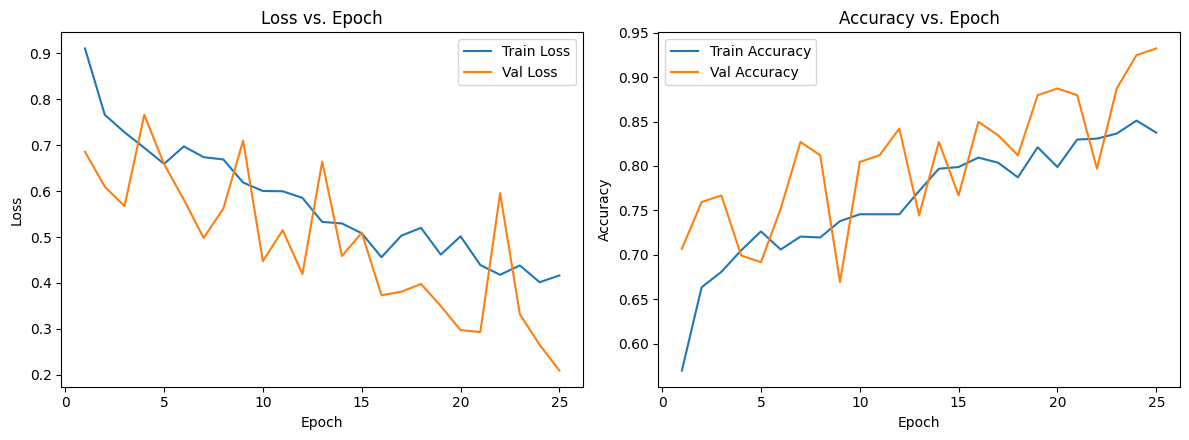

In [11]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss vs. Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy")
axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy")
axes[1].set_title("Accuracy vs. Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate Model on Test Set

Loading the best checkpoint (highest validation accuracy) and evaluate it once on the held-out test set.

In [12]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted")

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted)   : {recall:.4f}")
print(f"F1-score (weighted) : {f1:.4f}")
print()
print("Full classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


Test Accuracy : 0.8750
Precision (weighted): 0.8759
Recall (weighted)   : 0.8750
F1-score (weighted) : 0.8723

Full classification report:
                   precision    recall  f1-score   support

angular_leaf_spot     0.8478    0.9070    0.8764        43
        bean_rust     0.8889    0.7442    0.8101        43
          healthy     0.8913    0.9762    0.9318        42

         accuracy                         0.8750       128
        macro avg     0.8760    0.8758    0.8728       128
     weighted avg     0.8759    0.8750    0.8723       128



## 7. Visualizations — Confusion Matrix & Per-Class Performance

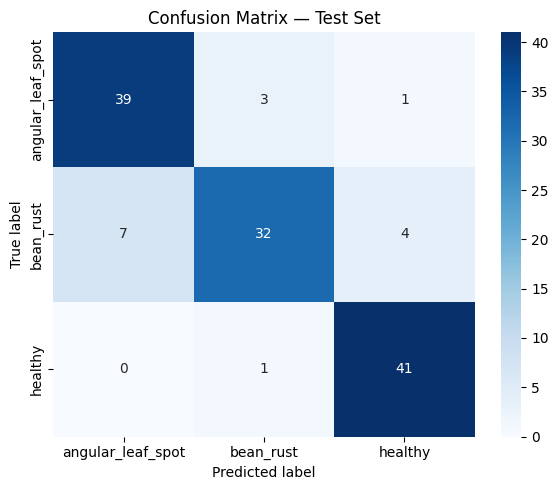

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


In [14]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = \
    precision_recall_fscore_support(all_labels, all_preds, average=None)

for i, cls in enumerate(class_names):
    print(f"{cls:>20s} | Precision: {per_class_precision[i]:.4f} | "
          f"Recall: {per_class_recall[i]:.4f} | F1: {per_class_f1[i]:.4f} | "
          f"Support: {per_class_support[i]}")

best_idx = int(np.argmax(per_class_f1))
worst_idx = int(np.argmin(per_class_f1))
print(f"\nBest performing class : {class_names[best_idx]} (F1={per_class_f1[best_idx]:.4f})")
print(f"Worst performing class: {class_names[worst_idx]} (F1={per_class_f1[worst_idx]:.4f})")


   angular_leaf_spot | Precision: 0.8478 | Recall: 0.9070 | F1: 0.8764 | Support: 43
           bean_rust | Precision: 0.8889 | Recall: 0.7442 | F1: 0.8101 | Support: 43
             healthy | Precision: 0.8913 | Recall: 0.9762 | F1: 0.9318 | Support: 42

Best performing class : healthy (F1=0.9318)
Worst performing class: bean_rust (F1=0.8101)


**Analysis & Discussion:**

The model achieved 87.50% test accuracy, with precision, recall, and F1 all close to that figure, showing no strong class bias. healthy performed best (F1: 0.9195) due to its visually distinctive appearance, while bean_rust performed worst (F1: 0.8148, recall: 0.7674), likely getting confused with angular_leaf_spot due to similar lesion-like textures. Training and validation curves tracked closely overall, with a brief instability around epoch 22 that recovered by epoch 24 — the checkpoint used for final evaluation. Dropout and augmentation likely helped keep validation performance in line with (or above) training performance, limiting overfitting despite the small dataset size.

## 9. Conclusions & Future Work

A compact, from-scratch CNN achieved 87.50% test accuracy classifying bean leaves into 3 categories, with a model size well under the 20MB limit. Future improvements could include transfer learning (ResNet18/MobileNetV2) for a likely accuracy boost, higher input resolution to capture finer lesion detail, more advanced augmentation (CutMix/MixUp), targeted error analysis between the two disease classes, and k-fold cross-validation for a more robust performance estimate.

In [15]:
FINAL_MODEL_PATH = "CNN_23-50953-1.pth"
torch.save(model.state_dict(), FINAL_MODEL_PATH)
print(f"Saved model weights to {FINAL_MODEL_PATH} "
      f"({os.path.getsize(FINAL_MODEL_PATH) / (1024**2):.2f} MB)")

loaded_model = CustomCNN(num_classes=num_classes).to(device)
loaded_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
loaded_model.eval()
print("Model successfully reloaded.")


Saved model weights to CNN_23-50953-1.pth (1.63 MB)
Model successfully reloaded.
